<a href="https://colab.research.google.com/github/tkacha467/end-to-end-ml-projects/blob/main/randomforest_DesicionTree_pimadiabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data=pd.read_csv('/content/drive/MyDrive/Marwadi_uiniversity/SEM-II/ML/Matereal/11-3/pima-indians-diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [40]:
# Split data into features and target variable
X = data.drop('Outcome', axis=1)
y = data['Outcome']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Random Forest Accuracy: 0.7272727272727273
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        99
           1       0.62      0.62      0.62        55

    accuracy                           0.73       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154

Random Forest Confusion Matrix:
[[78 21]
 [21 34]]


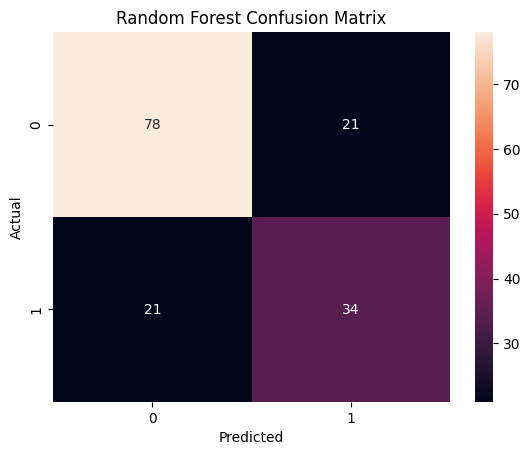

In [44]:
#For Random FOrest
# Train Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=150, random_state=42)
rf_classifier.fit(X_train_scaled, y_train)

# Predictions for Random Forest
rf_pred = rf_classifier.predict(X_test_scaled)

# Evaluate Random Forest model
rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))

# Confusion Matrix for Random Forest
rf_cm = confusion_matrix(y_test, rf_pred)
print("Random Forest Confusion Matrix:")
print(rf_cm)

# Visualization for Random Forest Confusion Matrix
plt.figure()
sns.heatmap(rf_cm, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Decision Tree (ID3) Accuracy: 0.7272727272727273
Decision Tree (ID3) Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.78        99
           1       0.61      0.65      0.63        55

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154

Decision Tree (ID3) Confusion Matrix:
[[76 23]
 [19 36]]


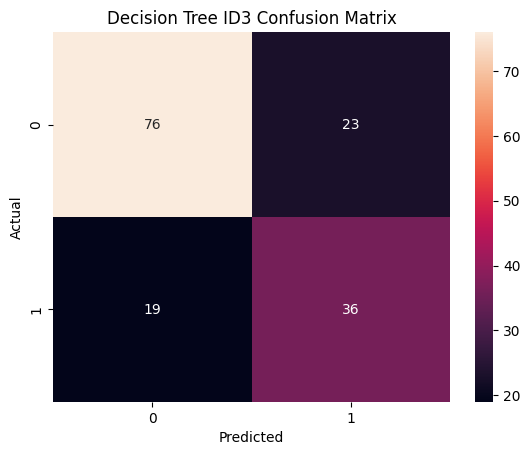

In [45]:
# Train Decision Tree classifier using ID3 (Entropy)
dt_id3 = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_id3.fit(X_train_scaled, y_train)

# Predictions for Decision Tree ID3
id3_pred = dt_id3.predict(X_test_scaled)

# Evaluate Decision Tree ID3 model
id3_acc = accuracy_score(y_test, id3_pred)

print("Decision Tree (ID3) Accuracy:", id3_acc)
print("Decision Tree (ID3) Classification Report:")
print(classification_report(y_test, id3_pred))

# Confusion Matrix for ID3
id3_cm = confusion_matrix(y_test, id3_pred)
print("Decision Tree (ID3) Confusion Matrix:")
print(id3_cm)

# Visualization for ID3 Confusion Matrix
plt.figure()
sns.heatmap(id3_cm, annot=True, fmt='d')
plt.title("Decision Tree ID3 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Decision Tree (CART) Accuracy: 0.7467532467532467
Decision Tree (CART) Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.76      0.79        99
           1       0.62      0.73      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154

Decision Tree (CART) Confusion Matrix:
[[75 24]
 [15 40]]


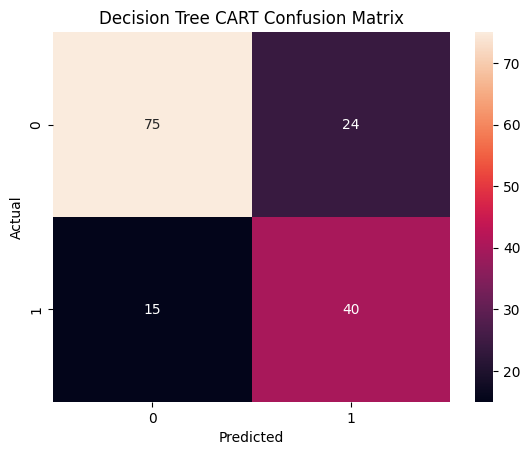

In [46]:
# Train Decision Tree classifier using CART (Gini)
dt_cart = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_cart.fit(X_train_scaled, y_train)

# Predictions for Decision Tree CART
cart_pred = dt_cart.predict(X_test_scaled)

# Evaluate Decision Tree CART model
cart_acc = accuracy_score(y_test, cart_pred)

print("Decision Tree (CART) Accuracy:", cart_acc)
print("Decision Tree (CART) Classification Report:")
print(classification_report(y_test, cart_pred))

# Confusion Matrix for CART
cart_cm = confusion_matrix(y_test, cart_pred)
print("Decision Tree (CART) Confusion Matrix:")
print(cart_cm)

# Visualization for CART Confusion Matrix
plt.figure()
sns.heatmap(cart_cm, annot=True, fmt='d')
plt.title("Decision Tree CART Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Feature Importance:
                    Feature  Importance
1                   Glucose    0.253162
5                       BMI    0.168074
7                       Age    0.146582
6  DiabetesPedigreeFunction    0.122334
2             BloodPressure    0.089085
0               Pregnancies    0.078084
4                   Insulin    0.077074
3             SkinThickness    0.065606


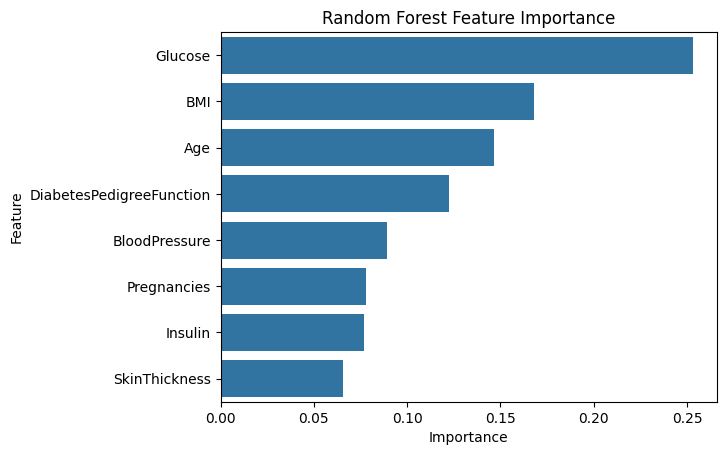

In [47]:
# Feature Importance for Random Forest
feature_importance = rf_classifier.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importance:")
print(importance_df)

# Visualization for Feature Importance
plt.figure()
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Random Forest Feature Importance")
plt.show()

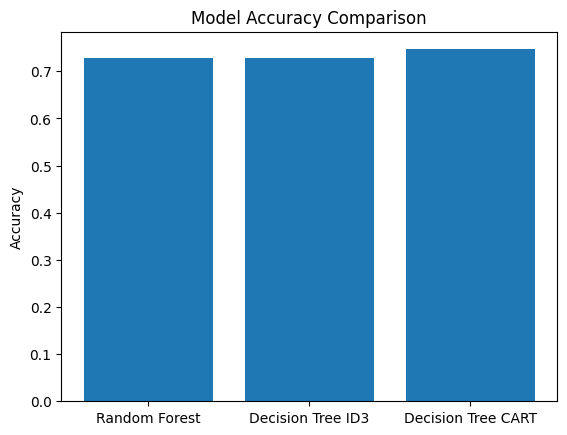

In [48]:
# Accuracy comparison visualization
models = ['Random Forest', 'Decision Tree ID3', 'Decision Tree CART']
accuracies = [rf_acc, id3_acc, cart_acc]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()